In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset, random_split,Subset
from torchvision.datasets import ImageFolder
from sklearn.metrics import  confusion_matrix
from torch.utils.data.sampler import WeightedRandomSampler
import copy
import random

/home/pcdm/anaconda3/envs/ming/lib/python3.11/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import sys

# 添加自定义模块的目录到模块搜索路径
sys.path.append('/home/pcdm/Desktop')

# 现在可以导入你的自定义模块
from MJPytorch import *

In [3]:
DATA_DIR = r'/home/pcdm/Desktop/indoor/Images'
model_algo="alexnet"

In [4]:

transform=transforms.Compose([
    transforms.Resize((229,229)),    
    transforms.ToTensor() 
])

In [5]:
#讀取資料且切分資料為train、valid、test

images=ImageDataset(DATA_DIR,transform,decision_mode=False)

generator = torch.Generator()
generator.manual_seed(124)

size = len(images)
valid_size = int(0.2 * size)

train_size = int(size - valid_size )

trainset, validset= random_split(images, (train_size, valid_size), generator=generator)


In [6]:
# create data loaders
batch_size =32 # larger numbers lead to CUDA running out of memory
train_dl = DataLoader(trainset,shuffle=True, batch_size=batch_size)
valid_dl = DataLoader(validset,shuffle=True, batch_size=batch_size)
criterion = nn.CrossEntropyLoss()

/home/pcdm/anaconda3/envs/ming/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch=0,train_loss=1.4225913831122248,train_accu=0.6357234314980794
Epoch=0,valid_loss=1.7715682430853459,valid_accu=0.5252880921895007
0
Epoch=1,train_loss=0.8002440224231129,train_accu=0.7796094750320103
Epoch=1,valid_loss=1.4713572854421813,valid_accu=0.5784250960307298
0
Epoch=2,train_loss=0.4425508160139321,train_accu=0.8840428937259923
Epoch=2,valid_loss=1.408523539727537,valid_accu=0.6053137003841229
0
Epoch=3,train_loss=0.2079688508573934,train_accu=0.9527048655569782
Epoch=3,valid_loss=1.4362402554510802,valid_accu=0.6139564660691421
0
Epoch=4,train_loss=0.16534118643376342,train_accu=0.9595870678617158
Epoch=4,valid_loss=1.5486638510883541,valid_accu=0.6024327784891165
Epoch=5,train_loss=0.07047421933794526,train_accu=0.9876760563380281
Epoch=5,valid_loss=1.5748358145260781,valid_accu=0.6126760563380281
Epoch=6,train_loss=0.057415863463271134,train_accu=0.9864756722151088
Epoch=6,valid_loss=1.7006586632869003,valid_accu=0.6049935979513444
Epoch=7,train_loss=0.0449433028304450

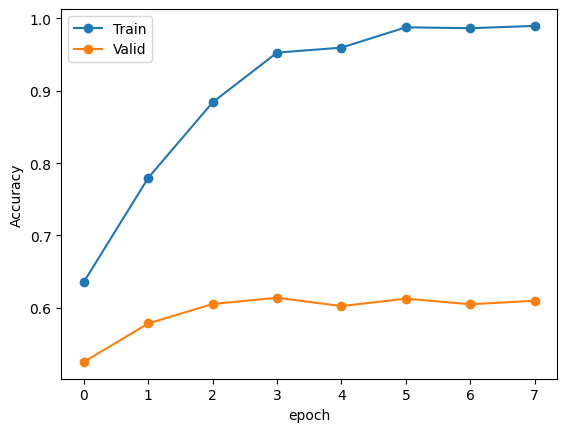

In [7]:
model_0=model_train(model_algo,train_dl,valid_dl,"0",70)
# model_0 = torch.load(f'model_{model_algo}_0_4.pth')

In [8]:
train_loss,train_accu,confusion_matrix_train=evaluate_model(model_0,train_dl,train_size,'0',mode='eval')
train_loss,train_accu

(0.207968850828774, 0.9527048655569782)

In [9]:
valid_loss,valid_accu,confusion_matrix_valid=evaluate_model(model_0,valid_dl,valid_size,'0',mode='eval')
valid_loss,valid_accu

(1.4362404789112595, 0.6139564660691421)

In [10]:
r=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(0)
p=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(1)

In [11]:
each_accu=2*p*r/(p+r)
each_accu

airport_inside    0.963580
artstudio         0.926407
auditorium        0.955224
bakery            0.956661
bar               0.969050
                    ...   
tv_studio         0.919708
videostore        0.931818
waitingroom       0.905830
warehouse         0.971429
winecellar        0.988180
Length: 67, dtype: float64

In [12]:
targetF=[x  for x in each_accu.nsmallest(35).index.map(trainset.dataset.classess)]
targetF

[49,
 56,
 50,
 40,
 64,
 20,
 5,
 62,
 35,
 60,
 24,
 22,
 41,
 1,
 32,
 31,
 9,
 17,
 55,
 63,
 38,
 8,
 36,
 29,
 37,
 47,
 42,
 54,
 7,
 21,
 43,
 45,
 2,
 3,
 6]

In [13]:
#將資料切分成true and false
def split_data(model_0,data_dl,split_mode):
    model_0.eval()
    indexF=[]
    indexT=[]
    with torch.no_grad():
        for (data,target,idx) in data_dl:
            data,target=data.cuda(),target.cuda()
            out = model_0(data)
            _, y_pred_tag = torch.max(out, dim = 1) 
            criterion = nn.CrossEntropyLoss(reduction='none')
            loss = criterion(out, target)
            softmax = torch.softmax(out, dim=1)
            # print(loss)
            for idx,loss,t,pred ,softmax in zip(idx,loss,target,y_pred_tag,softmax):
                if(split_mode[0]=='loss'):    
                    if(loss>split_mode[1]):
                        indexF.append(idx.cpu().numpy().item())  
                        data_dl.dataset.dataset.update_flag(idx)
                    # elif(loss>split_mode[1] and loss<split_mode[0]):
                    #    indexF.append(idx.cpu().numpy().item())  
                    #    indexT.append(idx.cpu().numpy().item())
                    else:
                        indexT.append(idx.cpu().numpy().item())  
                elif(split_mode=='TandF'):
                    
                    if(t!=pred):
                        indexF.append(idx.cpu().numpy().item())  
                        data_dl.dataset.dataset.update_flag(idx)
                    else:
                        indexT.append(idx.cpu().numpy().item())
                     
                   
                elif(split_mode[0]=='softmax'):
                 
                    if(softmax.max()<split_mode[1]):
                        indexF.append(idx.cpu().numpy().item())  
                        data_dl.dataset.dataset.update_flag(idx)
                    else:
                        indexT.append(idx.cpu().numpy().item())
                        if(softmax.max()<split_mode[2]):
                            indexF.append(idx.cpu().numpy().item())

                elif(split_mode[0]=='classaccu'):
                    if(t in split_mode[1]):
                        indexF.append(idx.cpu().numpy().item())  
                        data_dl.dataset.dataset.update_flag(idx)
                        if(t in [6,4,7,2]):
                            indexT.append(idx.cpu().numpy().item()) 
                            
                    else:
                        indexT.append(idx.cpu().numpy().item()) 
                        if(t in [6,4,7,2]):
                            indexF.append(idx.cpu().numpy().item()) 
                            
            torch.cuda.empty_cache() 
        return indexF,indexT

In [14]:
#將資料切分後建立dataset與dataloader
indexF=[]
indexT=[]
split_mode=('classaccu',targetF)
indexF,indexT=split_data(model_0,train_dl,split_mode)

Fdataset=Subset(images, indexF)
Tdataset=Subset(images, indexT)
Fdl=DataLoader(Fdataset, shuffle=True, batch_size=batch_size)
Tdl=DataLoader(Tdataset, shuffle=True, batch_size=batch_size)
len(indexF),len(indexT)

(7053, 6887)

In [15]:
indexF_v=[]
indexT_v=[]

indexF_v,indexT_v=split_data(model_0,valid_dl,split_mode)
len(indexF_v),len(indexT_v)

(1742, 1760)

In [16]:
Fdataset_v=Subset(images, indexF_v)
Tdataset_v=Subset(images, indexT_v)
Fdl_v=DataLoader(Fdataset_v, shuffle=True, batch_size=batch_size)
Tdl_v=DataLoader(Tdataset_v, shuffle=True, batch_size=batch_size)

In [17]:
#decision set
def decision_split(data_dl,model_0):
    flat_data=[]
    flat_true=[]
    with torch.no_grad():

        model_0.eval()   

        for data, target,idx in data_dl:

            data,target=data.to(device),target.to(device)
            out= model_0(data)
            softmax = torch.softmax(out, dim=1)
            _, y_pred_tag = torch.max(out, dim = 1) 

            for i,d,t in zip(idx,data,target):
                # if(t!=0):
                flat_true.append(int(data_dl.dataset.dataset.flag[i]))
                flat_data.append(d.cpu().numpy()) 
            
    return flat_data,flat_true

In [18]:
d_data,d_target=decision_split(train_dl,model_0)
d_v_data,d_v_target=decision_split(valid_dl,model_0)

In [19]:
decisionset=DecisionDataset(d_data,d_target)
decisionset_v=DecisionDataset(d_v_data,d_v_target)

In [20]:
#將模型建立框架後並訓練
def model_train(model_algo,train_dl,valid_dl,data_name,epochs,class_weight=None):

    if(data_name=="decision"):
        # model=model_create(model_algo,data_name,2)
        model=copy.deepcopy(model_0)
        model.classifier[6]=nn.Linear(model.classifier[6].in_features,2)
    elif(data_name=='T'or data_name=='F' or data_name=='F_f'or data_name=='T_f'):
        model=copy.deepcopy(model_0)
        model.classifier[6]=nn.Linear(model.classifier[6].in_features,len(train_dl.dataset.dataset.classes))

    else:
        model=model_create(model_algo,data_name,len(train_dl.dataset.dataset.classes))

    if(model_algo=='googlenet' or model_algo=='resnet18' or model_algo=='inception_v3' ):
        model_fc_layer=model.fc
    elif(model_algo=='efficientnet_b7' or model_algo=='mobilenet_v2'):
        model_fc_layer=model.classifier[1]
    else:
        model_fc_layer=model.classifier[6]


    if(data_name=="decision"):
        optim = torch.optim.Adam(model.classifier.parameters(), lr=1e-4)
        criterion = nn.CrossEntropyLoss() 

        model=trainer(epochs,model,criterion,optim,train_dl,valid_dl,data_name,model_algo)
    else:   
        optim = torch.optim.Adam(model.classifier.parameters(), lr=1e-4)
        criterion = nn.CrossEntropyLoss()
        model=trainer(epochs,model,criterion,optim,train_dl,valid_dl,data_name,model_algo)
    # torch.save(model, f"model_{model_algo}_{data_name}.pth")
    torch.cuda.empty_cache() 
    return model


Epoch=0,train_loss=0.16141973758323855,train_accu=0.9483034571062741
Epoch=0,valid_loss=0.373470464489982,valid_accu=0.8367477592829705
0
Epoch=1,train_loss=0.07837284535465334,train_accu=0.9807938540332907
Epoch=1,valid_loss=0.39556988936380294,valid_accu=0.8380281690140845
0
Epoch=2,train_loss=0.03827816615222206,train_accu=0.9943181818181818
Epoch=2,valid_loss=0.40510493902329753,valid_accu=0.8444302176696543
0
Epoch=3,train_loss=0.025375411170803098,train_accu=0.9950384122919335
Epoch=3,valid_loss=0.4686431466159381,valid_accu=0.8447503201024328
0
Epoch=4,train_loss=0.015897506047827258,train_accu=0.9969590268886044
Epoch=4,valid_loss=0.5176034946371437,valid_accu=0.8444302176696543
Epoch=5,train_loss=0.012597619718514268,train_accu=0.9968790012804097
Epoch=5,valid_loss=0.5908491914846222,valid_accu=0.8421895006402048
Epoch=6,train_loss=0.007820106385251574,train_accu=0.99895966709347
Epoch=6,valid_loss=0.5402002662000521,valid_accu=0.8482714468629962
0
Epoch=7,train_loss=0.0073727

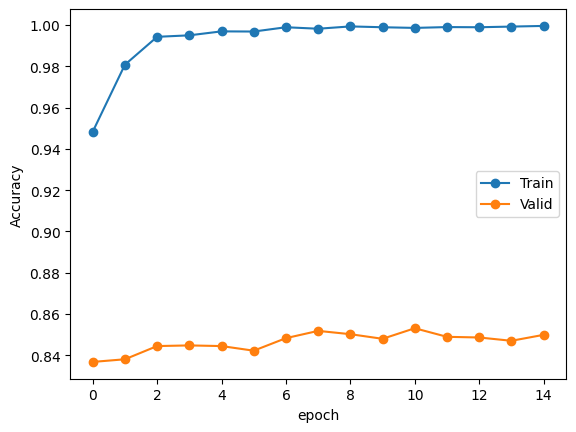

In [22]:
from torchsampler import ImbalancedDatasetSampler
decision_dl = DataLoader(decisionset, batch_size=32)
decision_v_dl = DataLoader(decisionset_v, batch_size=32)
model_decision=model_train(model_algo,decision_dl,decision_v_dl,"decision",70)

Epoch=0,train_loss=0.1268221783165456,train_accu=0.9680557572237549
Epoch=0,valid_loss=0.8670648417689584,valid_accu=0.7414772727272727
0
Epoch=1,train_loss=0.04715595596621531,train_accu=0.9915783359953536
Epoch=1,valid_loss=0.8951392875476317,valid_accu=0.7448863636363636
0
Epoch=2,train_loss=0.022031091397574906,train_accu=0.9963699724117904
Epoch=2,valid_loss=0.9416733075271954,valid_accu=0.7454545454545455
0
Epoch=3,train_loss=0.011799183390040399,train_accu=0.9979671845506026
Epoch=3,valid_loss=0.9382809243418954,valid_accu=0.7568181818181818
0
Epoch=4,train_loss=0.011712234773291365,train_accu=0.9976767823435458
Epoch=4,valid_loss=1.049583702737635,valid_accu=0.7517045454545455
Epoch=5,train_loss=0.005492259838528546,train_accu=0.9994191955858864
Epoch=5,valid_loss=1.0065810452808033,valid_accu=0.7659090909090909
0
Epoch=6,train_loss=0.008366674059779923,train_accu=0.9989835922753013
Epoch=6,valid_loss=1.126362445679578,valid_accu=0.7596590909090909
Epoch=7,train_loss=0.00889583

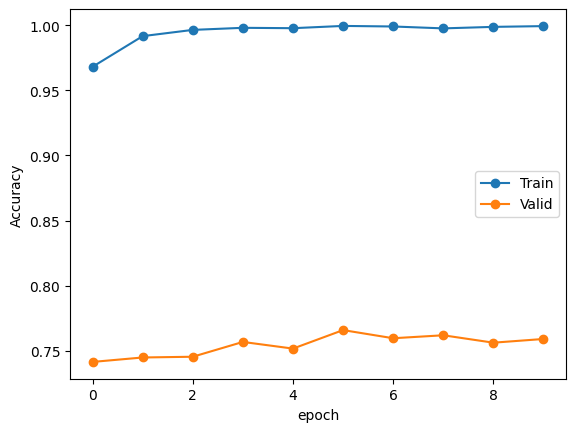

In [23]:
#訓練模型T、F、decision
model_T=model_train(model_algo,Tdl,Tdl_v,"T",70)
# model_T=torch.load(f'model_{model_algo}_T_1.pth')

Epoch=0,train_loss=0.295919900627216,train_accu=0.9310931518502765
Epoch=0,valid_loss=1.4004607865101435,valid_accu=0.5941446613088404
0
Epoch=1,train_loss=0.10613852771025219,train_accu=0.9795831561037857
Epoch=1,valid_loss=1.4389909419619258,valid_accu=0.605625717566016
0
Epoch=2,train_loss=0.05941158929340859,train_accu=0.9903587126045654
Epoch=2,valid_loss=1.5715497291457639,valid_accu=0.6044776119402985
Epoch=3,train_loss=0.027290389456613367,train_accu=0.9963136254076279
Epoch=3,valid_loss=1.6243507205139756,valid_accu=0.6194029850746269
0
Epoch=4,train_loss=0.01694477899215284,train_accu=0.9975896781511414
Epoch=4,valid_loss=1.6823357154800205,valid_accu=0.621699196326062
0
Epoch=5,train_loss=0.014535133911148966,train_accu=0.9980150290656459
Epoch=5,valid_loss=1.7176706993484059,valid_accu=0.6113662456946038
Epoch=6,train_loss=0.013960659167961456,train_accu=0.9978732454274777
Epoch=6,valid_loss=1.7731134304359777,valid_accu=0.6142365097588978
Epoch=7,train_loss=0.0166362076436

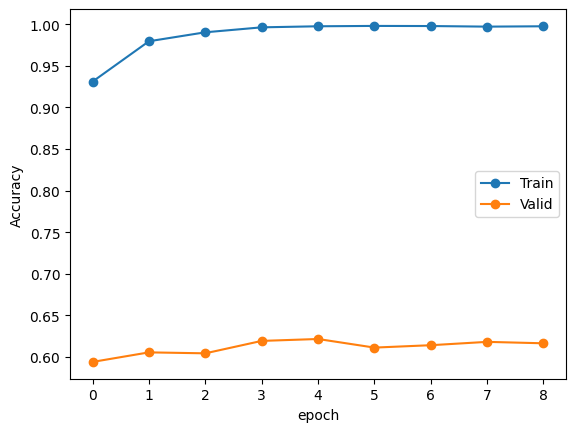

In [24]:
model_F=model_train(model_algo,Fdl,Fdl_v,"F",70)
#model_F=torch.load(f'model_{model_algo}_F_0.pth')

In [25]:
decision_loss,decision_accu,confusion_matrix_decision_train=evaluate_model(model_decision,decision_dl,len(decisionset),'decision',mode='eval')
confusion_matrix_decision_train= confusion_matrix_decision_train.rename(columns={"0":"False","1":"True"}, index={"0":"False","1":"True"})
decision_loss,decision_accu

(0.006654289508224722, 0.9986395646606914)

In [26]:
decision_valid_loss,decision_valid_accu,confusion_matrix_decision_valid=evaluate_model(model_decision,decision_v_dl,len(decisionset_v),'decision',mode='eval')
confusion_matrix_decision_valid= confusion_matrix_decision_valid.rename(columns={0:"False",1:"True"}, index={0:"False",1:"True"})
decision_valid_loss,decision_valid_accu

(0.6223601392838775, 0.8530729833546735)

In [27]:
T_loss,T_accu,confusion_matrix_T_train=evaluate_model(model_T,Tdl,len(Tdataset),'T',mode='eval')
T_loss,T_accu

(0.005492260360614161, 0.9994191955858864)

In [28]:
F_loss,F_accu,confusion_matrix_F_train=evaluate_model(model_F,Fdl,len(Fdataset),'F',mode='eval')
F_loss,F_accu

(0.016944779277438878, 0.9975896781511414)

In [29]:
T_valid_loss,T_valid_accu,confusion_matrix_T_valid=evaluate_model(model_T,Tdl_v,len(Tdataset_v),'T',mode='eval')
T_valid_loss,T_valid_accu

(1.0065810506994075, 0.7659090909090909)

In [30]:
F_valid_loss,F_valid_accu,confusion_matrix_F_valid=evaluate_model(model_F,Fdl_v,len(Fdataset_v),'F',mode='eval')
F_valid_loss,F_valid_accu

(1.6823356928973192, 0.621699196326062)

In [31]:
total_train_loss_d,total_train_accu_d,confusion_matrix_total_train,sum_all=total_model_evaluate_notdecision(train_dl,train_size,model_0,model_T,model_F)
total_train_loss_d,total_train_accu_d,sum_all

(0.011675536125736184, 0.9983994878361075, 6586)

In [32]:
total_valid_loss_d,total_valid_accu_d,confusion_matrix_total_valid_d,sum_all=total_model_evaluate_notdecision(valid_dl,valid_size,model_0,model_T,model_F)
total_valid_loss_d,total_valid_accu_d,sum_all

(1.3562733666081739, 0.6930217669654289, 1605)

In [33]:
total_train_loss,total_train_accu,confusion_matrix_total_train,sum_F,sum_T=total_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
total_train_loss,total_train_accu,sum_F,sum_T

(0.03492917347652897, 0.9972791293213829, 6573, 5923)

In [34]:
total_valid_loss,total_valid_accu,confusion_matrix_total_valid,sum_F,sum_T=total_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
total_valid_loss,total_valid_accu,sum_F,sum_T

(2.9928613550073817, 0.6245198463508322, 1558, 1566)

In [35]:
train_losses=[train_loss,decision_loss,T_loss,F_loss,total_train_loss,total_train_loss_d]
train_accuracies=[train_accu,decision_accu,T_accu,F_accu,total_train_accu,total_train_accu_d]
valid_losses=[valid_loss,decision_loss,T_valid_loss,F_valid_loss,total_valid_loss,total_valid_loss_d]
valid_accuracies=[valid_accu,decision_valid_accu,T_valid_accu,F_valid_accu,total_valid_accu,total_valid_accu_d]

In [36]:
model_algos=['Model_0','Model_Decision',"Model_T","Model_F","Total_Model",'Total_Model_without_decision']
data = {
    'Model': model_algos,
    'Train Loss': train_losses,
    'Train Accuracy': train_accuracies,
    'Valid Loss': valid_losses,
    'Valid Accuracy': valid_accuracies
}
df = pd.DataFrame(data)
df

,Model,Train Loss,Train Accuracy,Valid Loss,Valid Accuracy
0,Model_0,0.207969,0.952705,1.436240,0.613956
1,Model_Decision,0.006654,0.998640,0.006654,0.853073
2,Model_T,0.005492,0.999419,1.006581,0.765909
3,Model_F,0.016945,0.997590,1.682336,0.621699
4,Total_Model,0.034929,0.997279,2.992861,0.624520
5,Total_Model_without_decision,0.011676,0.998399,1.356273,0.693022


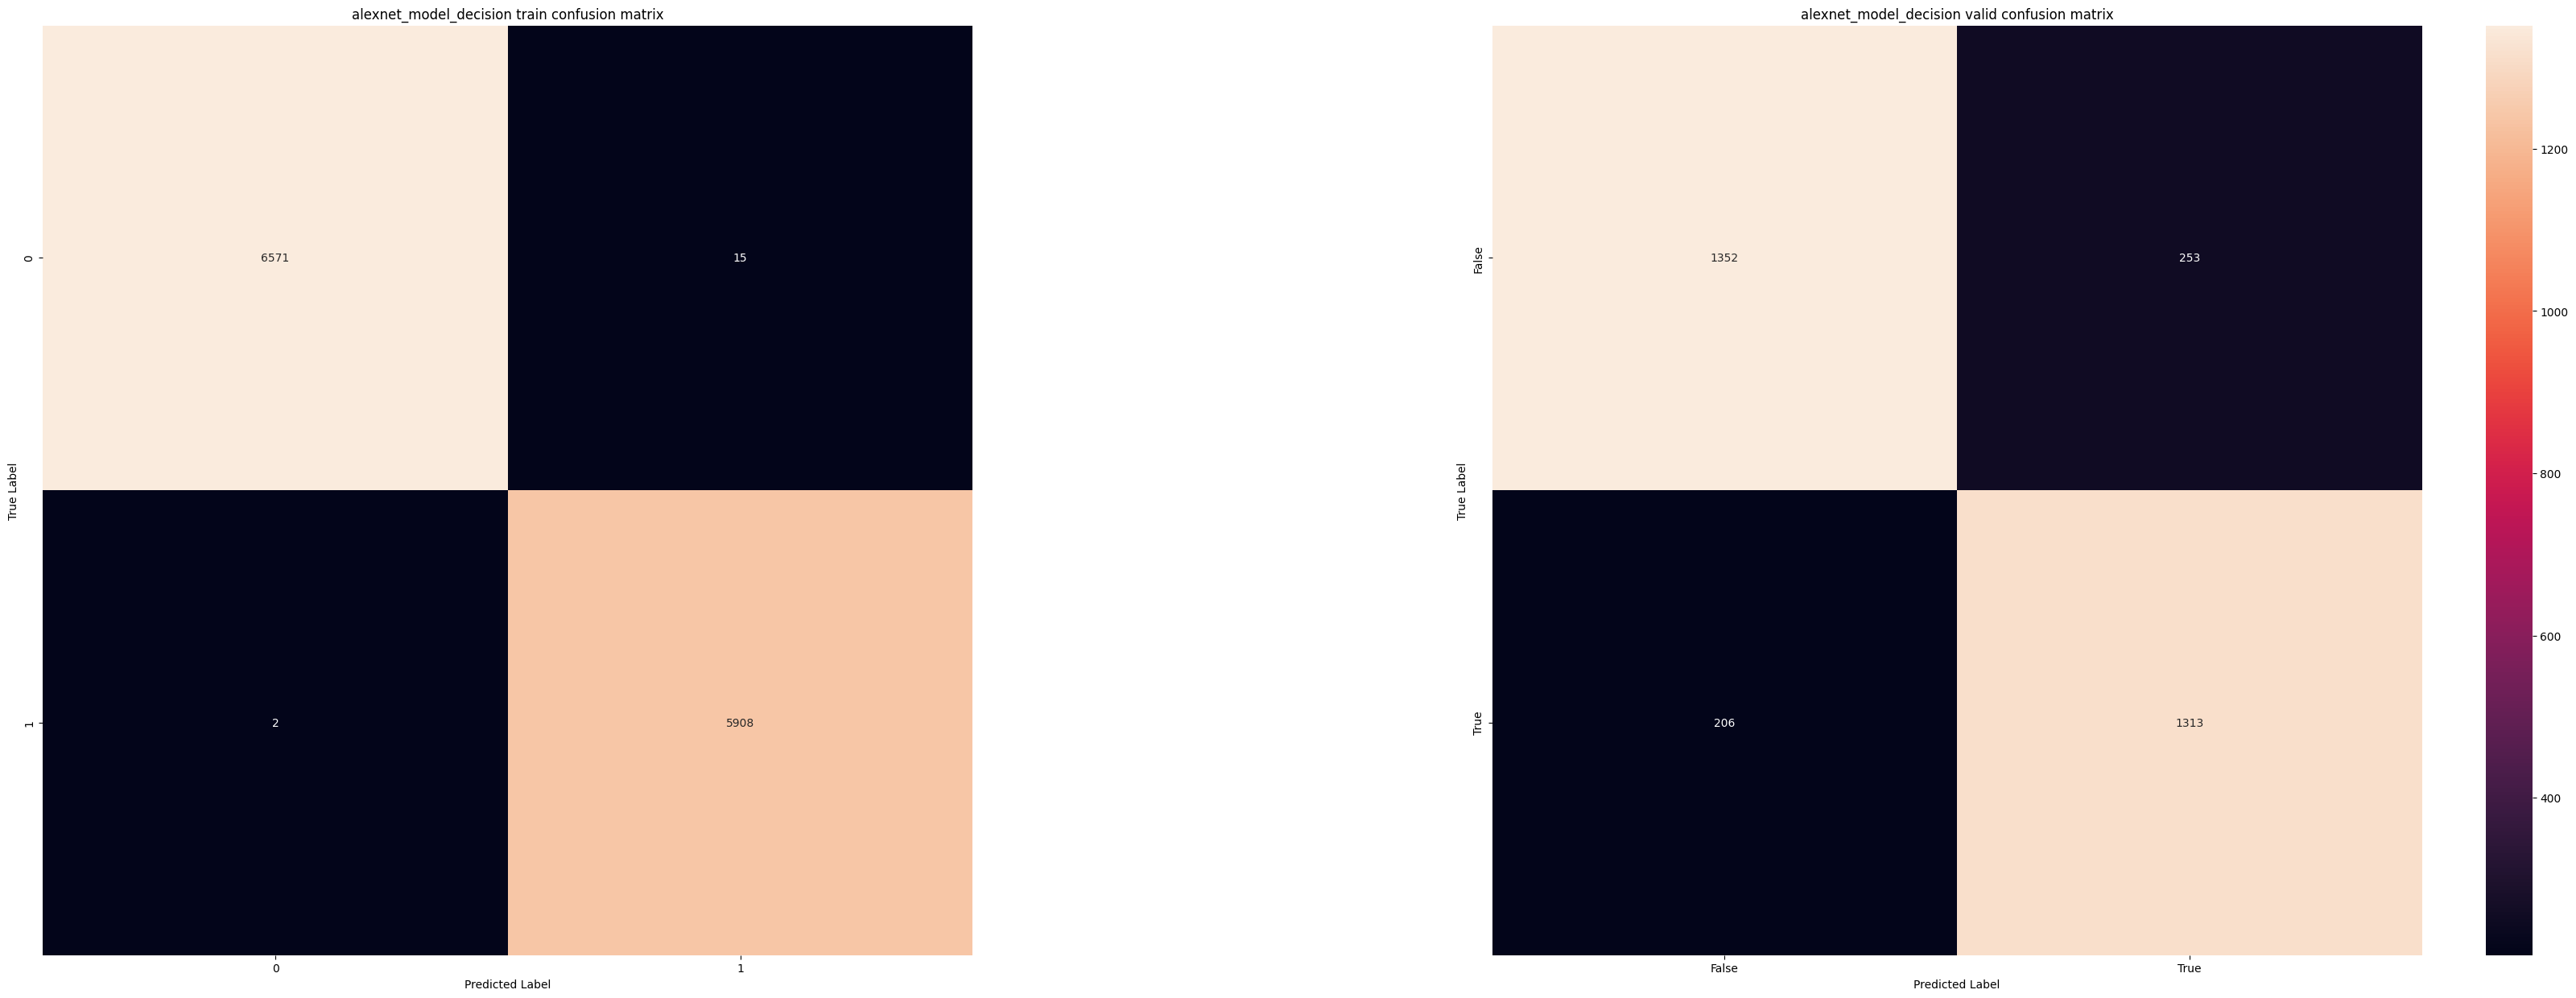

In [37]:
plot_confusion_matrix(confusion_matrix_decision_train,confusion_matrix_decision_valid,"model_decision",model_algo)

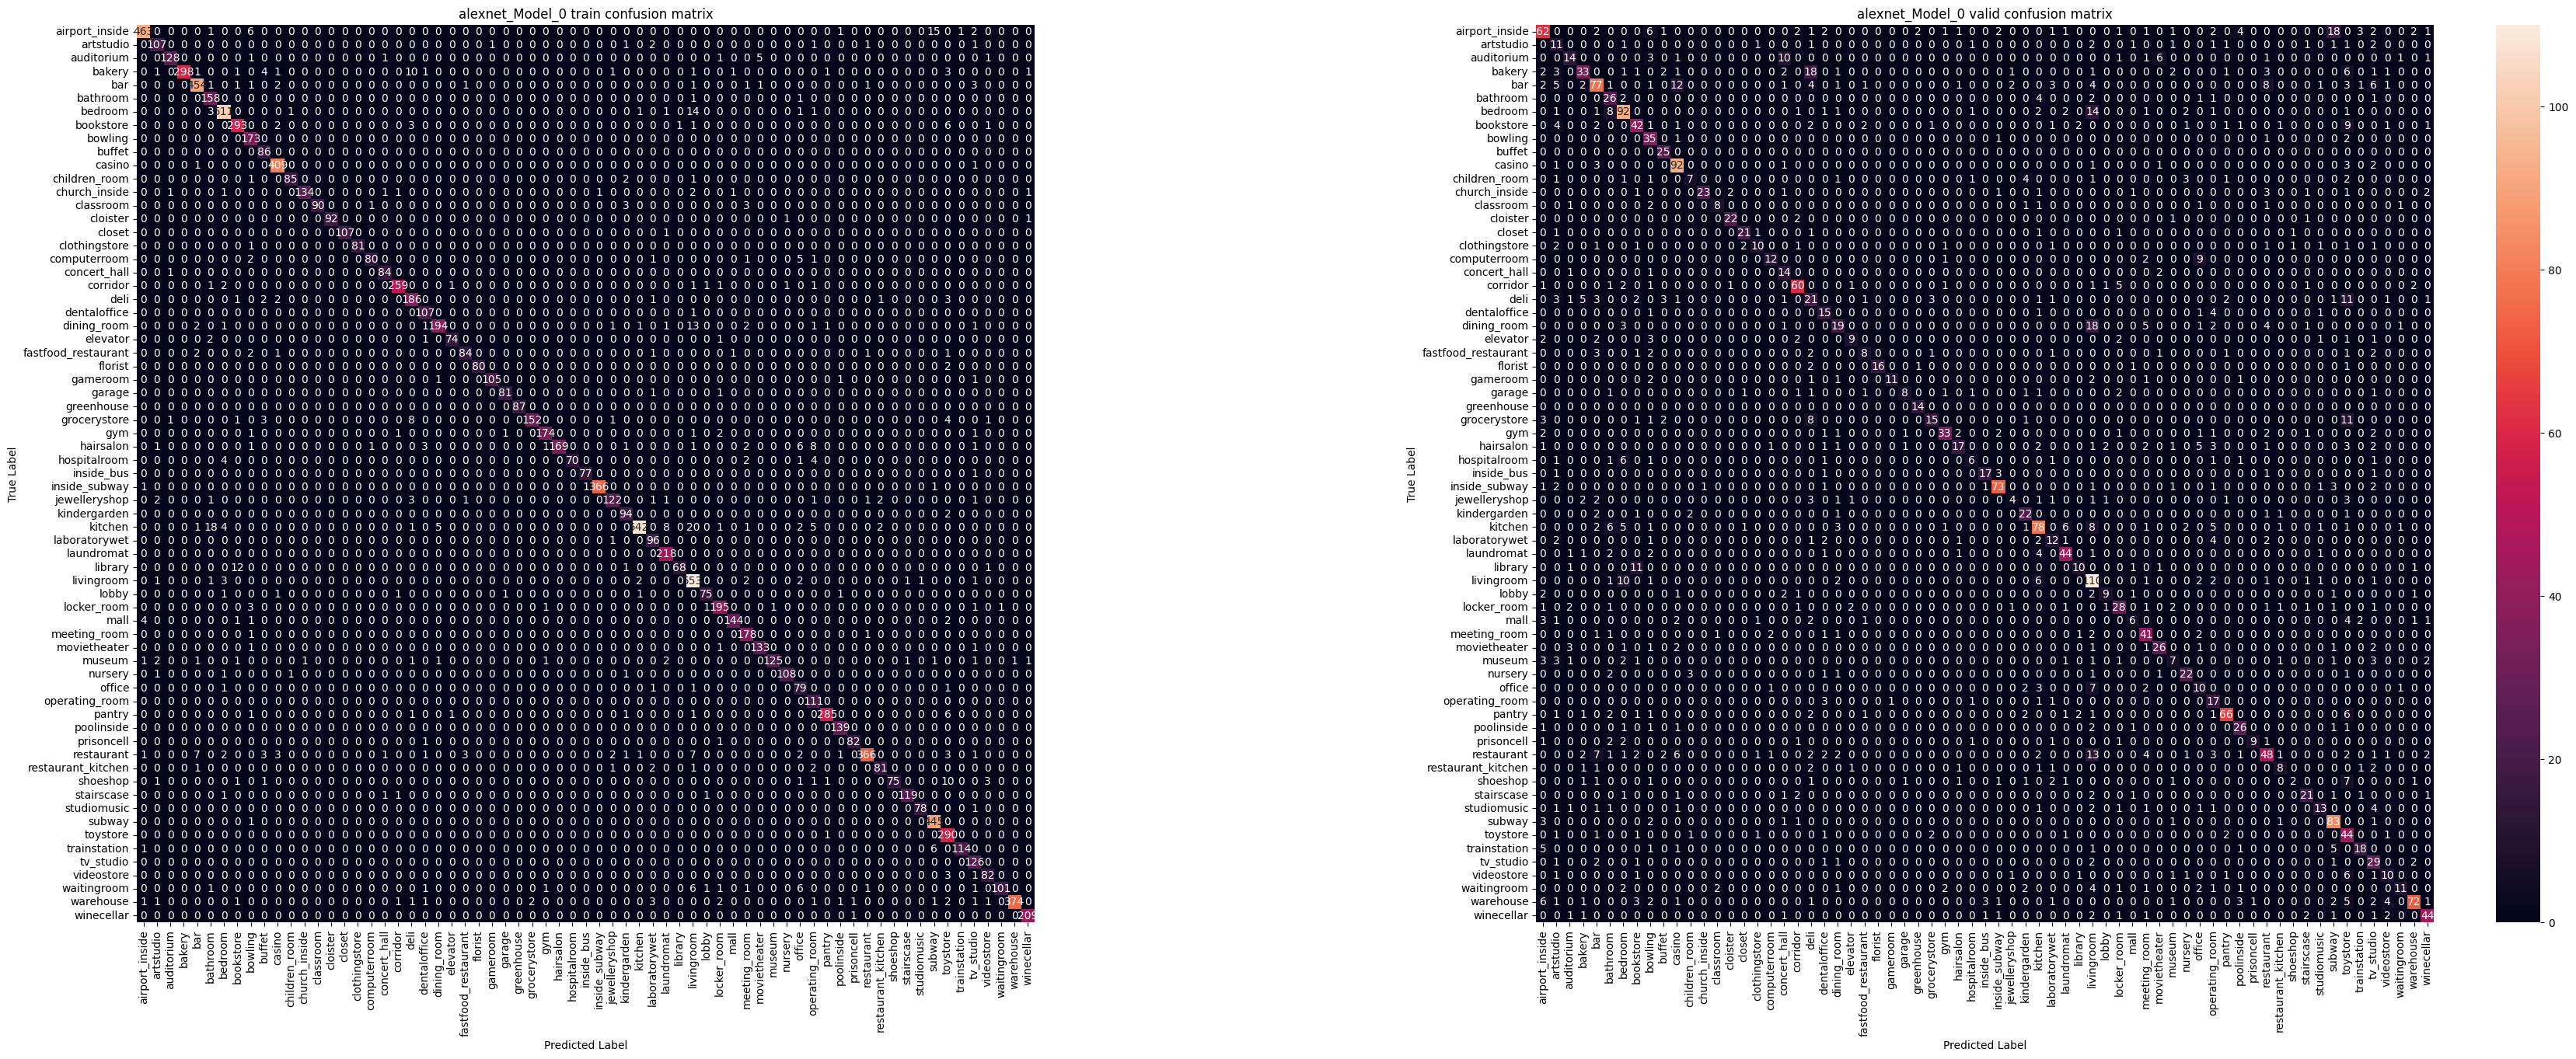

In [38]:
plot_confusion_matrix(confusion_matrix_train,confusion_matrix_valid,"Model_0",model_algo)

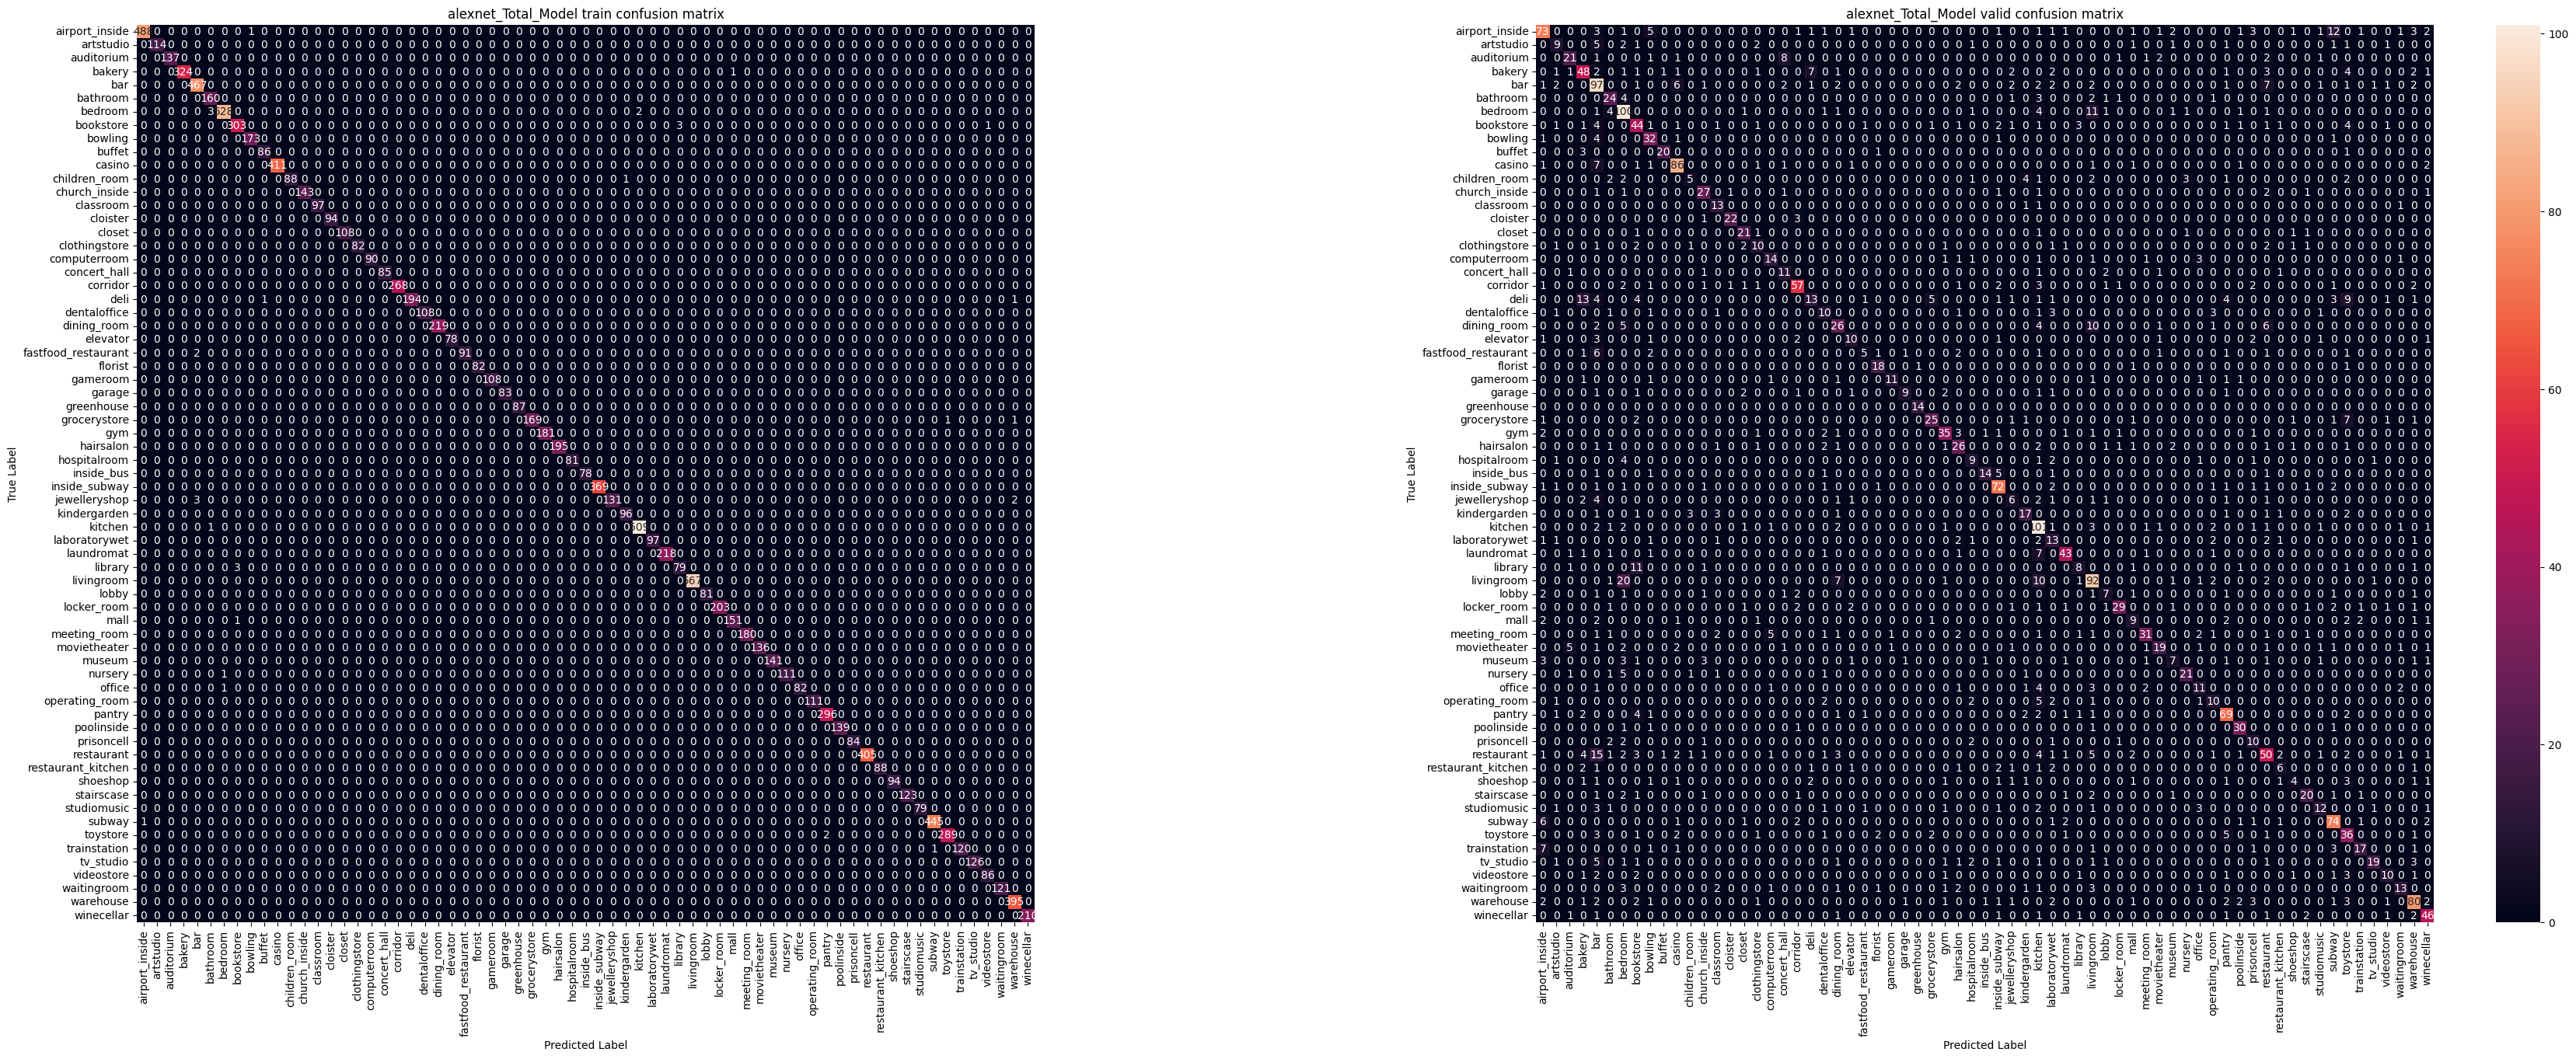

In [39]:
plot_confusion_matrix(confusion_matrix_total_train,confusion_matrix_total_valid,"Total_Model",model_algo)

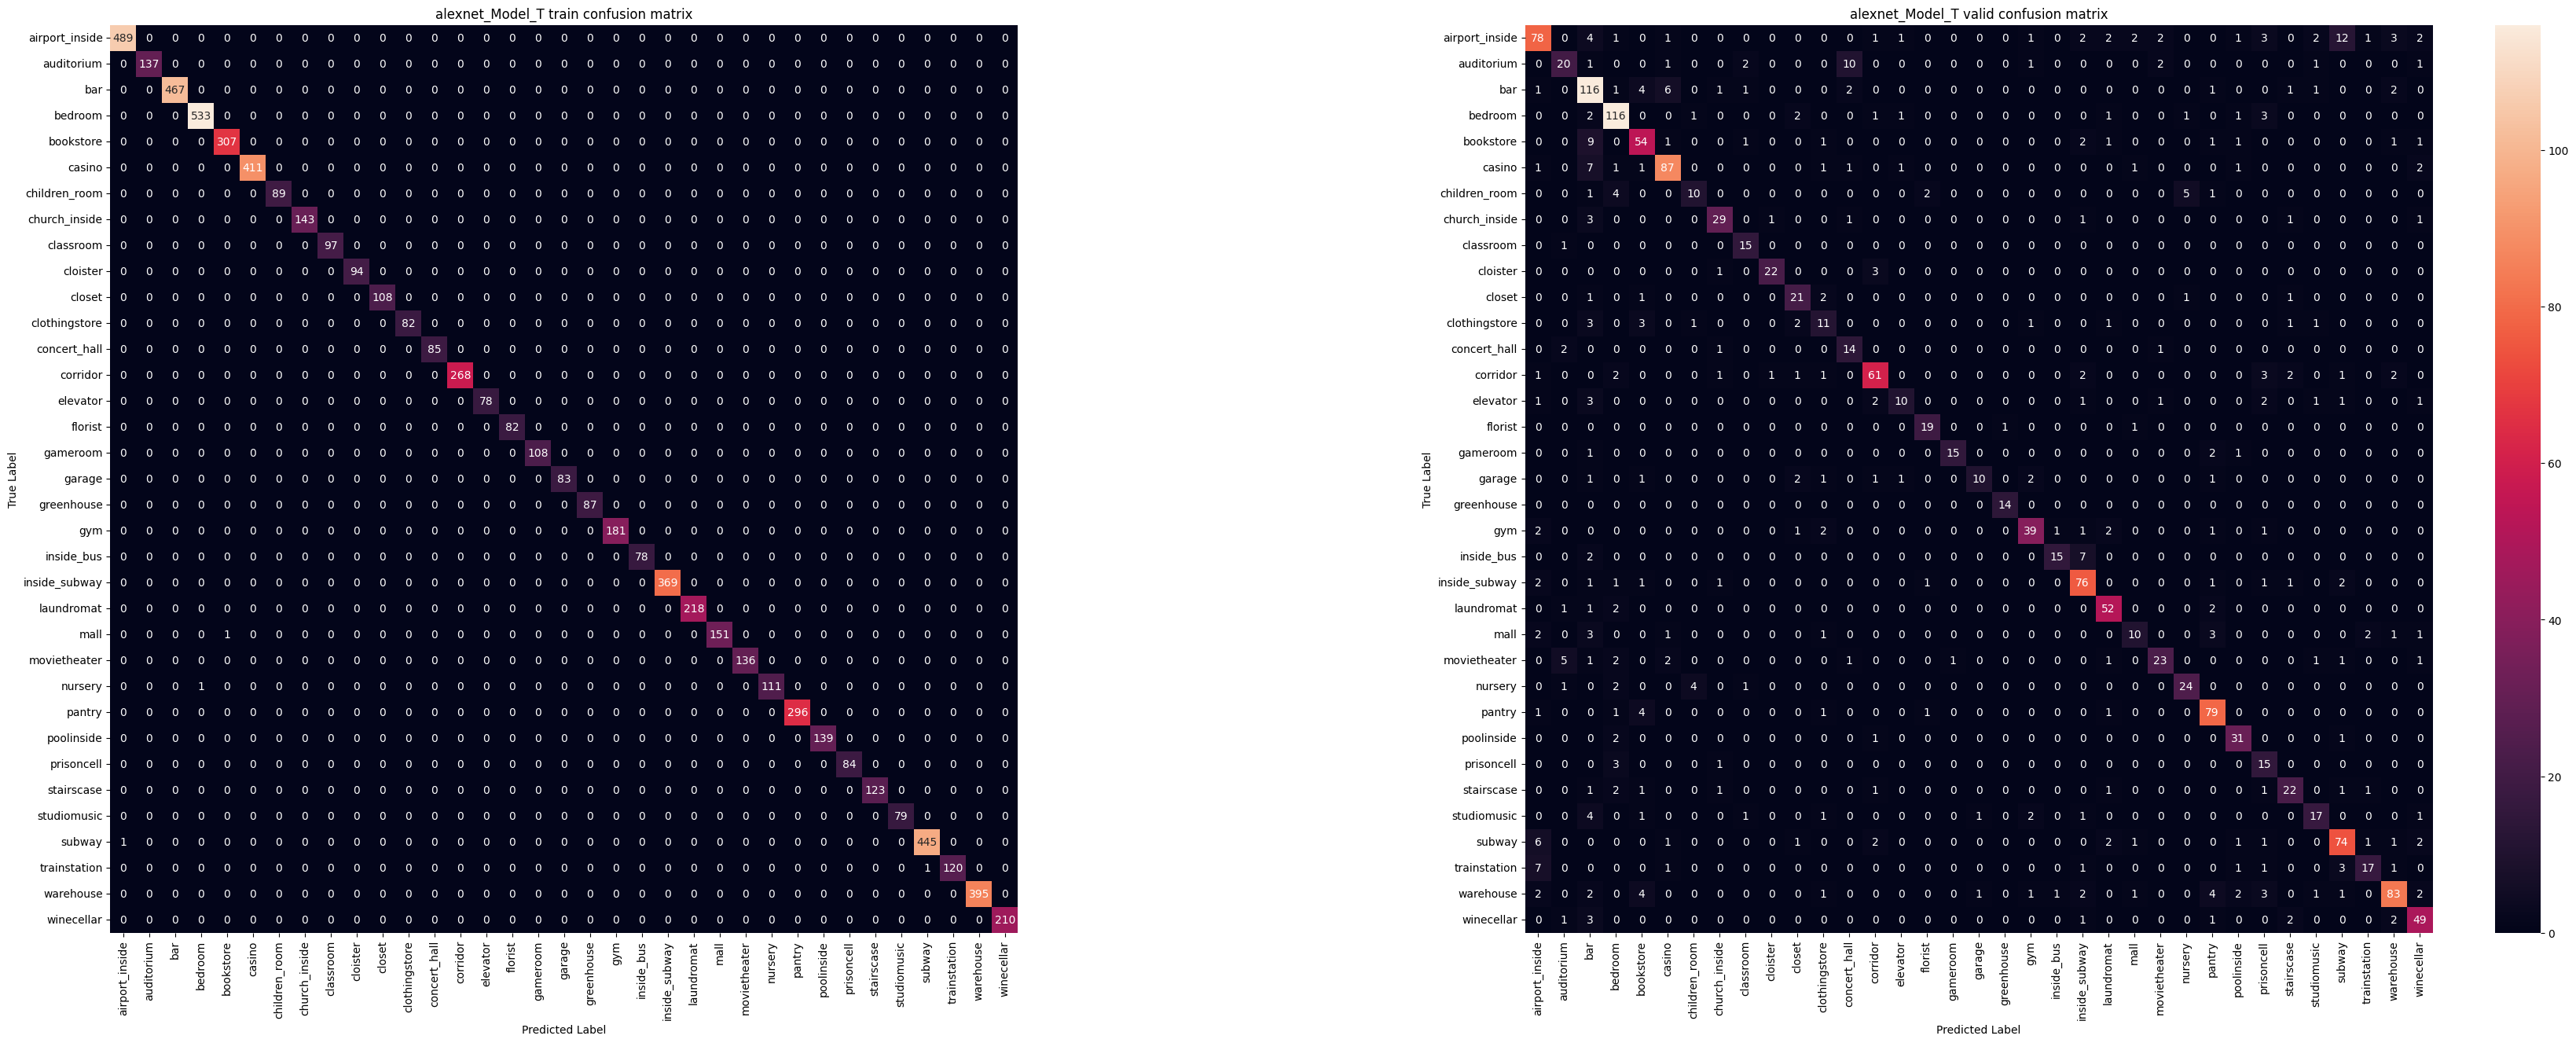

In [40]:
plot_confusion_matrix(confusion_matrix_T_train,confusion_matrix_T_valid,"Model_T",model_algo)

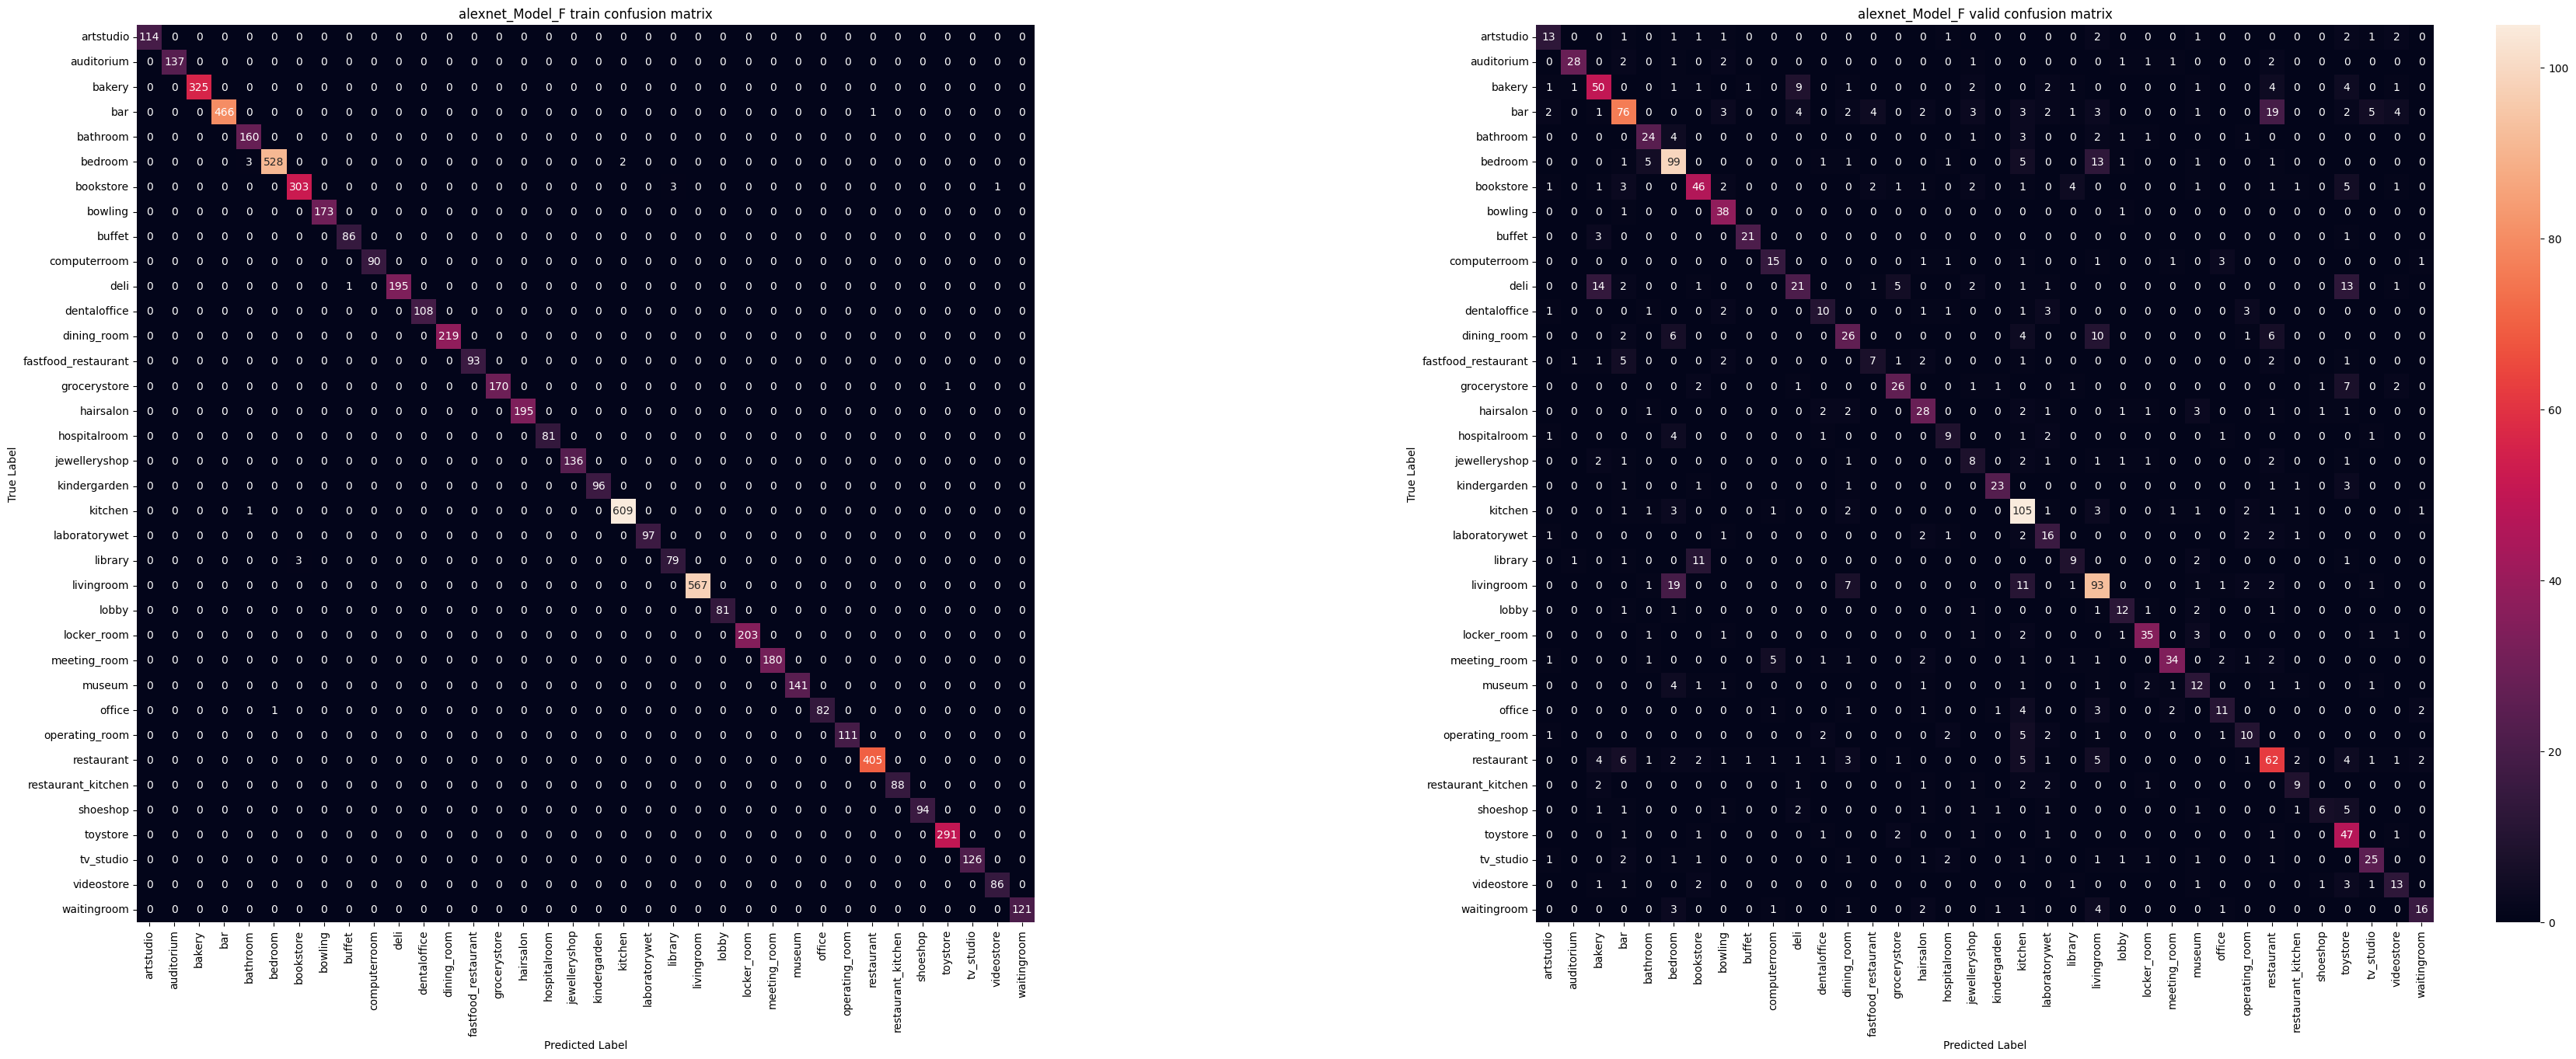

In [41]:
plot_confusion_matrix(confusion_matrix_F_train,confusion_matrix_F_valid,"Model_F",model_algo)

In [42]:
#全部模型裝在一起的表現
def show_model_evaluate(data_dl,size,model_0,model_T,model_F):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    results = []
    
    with torch.no_grad():
        for data,target,idx in data_dl:
   
            data,target=data.to(device),target.to(device) 
            
            for d,t,idx in zip(data,target,idx):
                
                pred_F=torch.max(model_F(d.unsqueeze(0)), dim = 1).indices.item()
                pred_T=torch.max(model_T(d.unsqueeze(0)), dim = 1).indices.item()
                pred_0=torch.max(model_0(d.unsqueeze(0)), dim = 1).indices.item()
                
                    # Record results in a dictionary
                result_dict = {
                    'Index': idx.item(),
                    'Target': t.item(),
                    'Pred_F': pred_F,
                    'Pred_T': pred_T,
                    'Pred_0': pred_0,
                    'Match_F': pred_F == t.item(),
                    'Match_T': pred_T == t.item(),
                    'Match_0': pred_0 == t.item()
                }

                # Append result dictionary to the results list
                results.append(result_dict)

    # Create a DataFrame from the results list
    df_results = pd.DataFrame(results)
    return  df_results

In [43]:

sum_all=0
with torch.no_grad():
    for data,target,idx in train_dl:
 
        data,target=data.to(device),target.to(device)
        out_growth = model_0(data)
        softmax_0=torch.softmax(out_growth, dim=1)

        out_T = model_T(data)
        softmax_T=torch.softmax(out_T, dim=1)

        out_F = model_F(data)
        softmax_F=torch.softmax(out_F, dim=1)
    
        for st,sf,d,idx,t in zip(softmax_T,softmax_F,data,idx,target):
         
            st_max=torch.max(st).item()
            sf_max=torch.max(sf).item()
        
            if(sf_max>st_max):
                if(t in targetF):
                    sum_all+=1
            else:
                if(t not in targetF):
                    sum_all+=1
    sum_all=sum_all/train_size

sum_all

0.8728393085787451

In [44]:
sum_all=0
with torch.no_grad():
    for data,target,idx in valid_dl:
 
        data,target=data.to(device),target.to(device)
        out_growth = model_0(data)
        softmax_0=torch.softmax(out_growth, dim=1)

        out_T = model_T(data)
        softmax_T=torch.softmax(out_T, dim=1)

        out_F = model_F(data)
        softmax_F=torch.softmax(out_F, dim=1)
    
        for st,sf,d,idx,t in zip(softmax_T,softmax_F,data,idx,target):
         
            st_max=torch.max(st).item()
            sf_max=torch.max(sf).item()
        
            if(sf_max>st_max):
                if(t in targetF):
                    sum_all+=1
            else:
                if(t not in targetF):
                    sum_all+=1
    sum_all=sum_all/valid_size
sum_all

0.6190781049935979

In [45]:
#全部模型裝在一起的表現
def total_model_softmax_evaluate(data_dl,size,model_0,model_T,model_F,model_decision):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    sum_F=0
    sum_T=0
    with torch.no_grad():
        for data,target,idx in data_dl:
            outputs=[]
            data,target=data.to(device),target.to(device)
            out_growth = model_0(data)
            softmax_0=torch.softmax(out_growth, dim=1)

            out_T = model_T(data)
            softmax_T=torch.softmax(out_T, dim=1)

            out_F = model_F(data)
            softmax_F=torch.softmax(out_F, dim=1)
       
            for s0,st,sf,d in zip(softmax_0,softmax_T,softmax_F,data):
               
                st_max=torch.max(st).item()
                sf_max=torch.max(sf).item()

                st_max_z=calculate_zscore(st_max,avg_T,max_softmax_T,min_softmax_T)
                sf_max_z=calculate_zscore(sf_max,avg_F,max_softmax_F,min_softmax_F)
               
                if(sf_max_z>st_max_z):
                    outputs.append(model_F(d.unsqueeze(0)))
                    sum_F+=1
                else:
                    outputs.append(model_T(d.unsqueeze(0)))
                    sum_T+=1

            outputs = torch.cat(outputs, dim=0)
            _, y_pred_tag = torch.max(outputs, dim = 1)
            loss = criterion(outputs, target)


            flat_true.extend(target.cpu().numpy())
            flat_pred.extend(y_pred_tag.cpu().numpy())

            total_loss+= loss.item()*data.size(0)
            correct=torch.sum(y_pred_tag == target).item()
            accu += correct      

    total_loss=total_loss/size
    accu=accu/size
    idx2class = {v: k for k, v in data_dl.dataset.dataset.classes}
    confusion_matrix_total = pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
    return total_loss,accu,confusion_matrix_total,sum_F,sum_T

In [46]:
def calculate_zscore(softmax,avg,max_softmax,min_softmax):
    return (softmax-avg)/(max_softmax-min_softmax)

In [47]:
def calculate_lcb(data_dl,model):

    softmax_max_list = []

    # 计算每张图片的 softmax 最大值并添加到列表中
    with torch.no_grad():
        for images, labels,idx in data_dl:
            images = images.to(device)
            outputs = model(images)
            softmax_outputs = torch.softmax(outputs, dim=1)
            max_values, _ = torch.max(softmax_outputs, dim=1)
            softmax_max_list.extend(max_values.cpu().numpy())

    # 计算平均值
    avg = sum(softmax_max_list)/len(softmax_max_list)
    std = torch.tensor(softmax_max_list).std().item()

    lcb=avg-std

    max_softmax=max(softmax_max_list)
    min_softmax=min(softmax_max_list)

    return lcb,avg,std,max_softmax,min_softmax


In [48]:
##TT
lcb_T,avg_T,std_T,max_softmax_T,min_softmax_T=calculate_lcb(Tdl,model_T)
lcb_T,avg_T,std_T
##FF
lcb_F,avg_F,std_F,max_softmax_F,min_softmax_F=calculate_lcb(Fdl,model_F)
lcb_F,avg_F,std_F

(0.9535847398446254, 0.9888569395051651, 0.03527219966053963)

In [49]:
total_loss,accu,confusion_matrix_total,sum_F,sum_T=total_model_softmax_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
total_loss,accu,sum_F,sum_T

(1.6000555984038805, 0.9235755441741357, 7204, 5292)

In [50]:
total_loss,accu,confusion_matrix_total,sum_F,sum_T=total_model_softmax_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
total_loss,accu,sum_F,sum_T

(6.416156931204314, 0.532010243277849, 1606, 1518)

In [51]:
sum_all=0
with torch.no_grad():
    for data,target,idx in train_dl:
 
        data,target=data.to(device),target.to(device)
        out_growth = model_0(data)
        softmax_0=torch.softmax(out_growth, dim=1)

        out_T = model_T(data)
        softmax_T=torch.softmax(out_T, dim=1)

        out_F = model_F(data)
        softmax_F=torch.softmax(out_F, dim=1)
    
        for st,sf,d,idx,t in zip(softmax_T,softmax_F,data,idx,target):
         
            st_max=torch.max(st).item()
            sf_max=torch.max(sf).item()
            
            st_max_z=calculate_zscore(st_max,avg_T,max_softmax_T,min_softmax_T)
            sf_max_z=calculate_zscore(sf_max,avg_F,max_softmax_F,min_softmax_F)

            if(sf_max_z>st_max_z):
                if(t in targetF):
                    sum_all+=1
            else:
                if(t not in targetF):
                    sum_all+=1
    sum_all=sum_all/train_size

sum_all

0.8830025608194623

In [52]:
sum_all=0
with torch.no_grad():
    for data,target,idx in valid_dl:
 
        data,target=data.to(device),target.to(device)
        out_growth = model_0(data)
        softmax_0=torch.softmax(out_growth, dim=1)

        out_T = model_T(data)
        softmax_T=torch.softmax(out_T, dim=1)

        out_F = model_F(data)
        softmax_F=torch.softmax(out_F, dim=1)
    
        for st,sf,d,idx,t in zip(softmax_T,softmax_F,data,idx,target):
         
            st_max=torch.max(st).item()
            sf_max=torch.max(sf).item()
        
            st_max_z=calculate_zscore(st_max,avg_T,max_softmax_T,min_softmax_T)
            sf_max_z=calculate_zscore(sf_max,avg_F,max_softmax_F,min_softmax_F)

            if(sf_max_z>st_max_z):
                if(t in targetF):
                    sum_all+=1
            else:
                if(t not in targetF):
                    sum_all+=1
    sum_all=sum_all/valid_size
sum_all

0.6245198463508322

In [53]:
def show_model_evaluate(data_dl,size,model_0,model_T,model_F):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    results = []
    
    with torch.no_grad():
        for data,target,idx in data_dl:
   
            data,target=data.to(device),target.to(device) 
            
            for d,t,idx in zip(data,target,idx):
                
                output_F=model_F(d.unsqueeze(0))
                output_T=model_T(d.unsqueeze(0))
                output_0=model_0(d.unsqueeze(0))
                output_decision=model_decision(d.unsqueeze(0))

                pred_F=torch.max(output_F, dim = 1).indices.item()
                pred_T=torch.max(output_T, dim = 1).indices.item()
                pred_0=torch.max(output_0, dim = 1).indices.item()
                pred_decision=torch.max(output_decision, dim = 1).indices.item()

                softmax_F=torch.max(torch.softmax(output_F, dim=1)).item()
                softmax_T=torch.max(torch.softmax(output_T, dim=1)).item()
                softmax_0=torch.max(torch.softmax(output_0, dim=1)).item()
                softmax_decision=torch.max(torch.softmax(output_decision, dim=1)).item()
                
                # Record results in a dictionary
                result_dict = {
                    'Index': idx.item(),
                    'Target': t.item(),
                    'Pred_F': pred_F,
                    'Pred_T': pred_T,
                    'Pred_0': pred_0,

                    'Softmax_F': softmax_F,
                    'Softmax_T': softmax_T,
                    'Softmax_0': softmax_0,
                    'Softmax_decision': softmax_decision,
                    
                    'Match_F': pred_F == t.item(),
                    'Match_T': pred_T == t.item(),
                    'Match_0': pred_0 == t.item(),
                    'Decision':bool(pred_decision),
                    'flag':data_dl.dataset.dataset.flag[idx]

                }

                # Append result dictionary to the results list
                results.append(result_dict)

    # Create a DataFrame from the results list
    df_results = pd.DataFrame(results)
    return  df_results

In [54]:
df_results=show_model_evaluate(train_dl,train_size,model_0,model_T,model_F)
df_results

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
0,6051,23,43,23,23,0.999882,0.998917,0.551525,1.000000,False,True,True,True,True
1,4226,12,6,12,12,0.483292,0.998072,0.639529,0.999484,False,True,True,True,True
2,4299,12,4,12,12,0.954775,0.999518,0.475216,0.999954,False,True,True,True,True
3,10165,41,41,11,41,0.995470,0.961341,0.916722,0.996971,True,False,True,False,False
4,9698,41,41,6,41,0.999671,0.999956,0.999742,1.000000,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12491,1191,3,3,7,3,0.999716,0.792483,0.981994,0.999666,True,False,True,False,False
12492,5719,21,21,23,21,0.997127,0.747073,0.999760,1.000000,True,False,True,False,False
12493,15259,65,7,65,65,0.499087,0.999995,0.999667,1.000000,False,True,True,True,True
12494,5833,22,22,6,22,0.955480,0.982086,0.537854,0.999997,True,False,True,False,False


In [55]:
df_results[(df_results['Decision']!=df_results['flag']) & (df_results['Softmax_decision']<0.85)]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
16,8130,35,35,65,35,0.999032,0.565751,0.945841,0.511469,True,False,True,True,False
1949,8006,35,35,4,35,0.977085,0.952847,0.709715,0.776615,True,False,True,True,False
2632,5447,20,20,65,20,0.933291,0.990665,0.826610,0.696773,True,False,True,True,False
3598,2785,6,6,6,6,0.995568,0.994884,0.350769,0.849747,True,True,True,True,False
6046,14154,60,60,51,60,0.999471,0.996505,0.914350,0.540194,True,False,True,True,False
7418,2946,7,7,7,7,0.993615,0.987631,0.481801,0.585033,True,True,True,True,False
7558,854,2,2,2,46,0.999998,0.991852,0.622017,0.594569,True,True,False,True,False
8922,8087,35,35,4,35,0.998043,0.999950,0.915079,0.694498,True,False,True,True,False
9583,6821,29,29,65,29,0.999566,0.999168,0.443761,0.774917,True,False,True,True,False
9941,6122,24,24,4,24,0.994024,0.989600,0.751618,0.755764,True,False,True,True,False


In [59]:
df_results[df_results['Decision']!=df_results['flag']]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
16,8130,35,35,65,35,0.999032,0.565751,0.945841,0.511469,True,False,True,True,False
1949,8006,35,35,4,35,0.977085,0.952847,0.709715,0.776615,True,False,True,True,False
2632,5447,20,20,65,20,0.933291,0.990665,0.826610,0.696773,True,False,True,True,False
3598,2785,6,6,6,6,0.995568,0.994884,0.350769,0.849747,True,True,True,True,False
4182,8004,35,35,4,35,0.999869,0.999988,0.970495,0.955661,True,False,True,True,False
6046,14154,60,60,51,60,0.999471,0.996505,0.914350,0.540194,True,False,True,True,False
6530,4096,11,36,11,36,0.999286,0.999618,0.724395,0.981644,False,True,False,False,True
7418,2946,7,7,7,7,0.993615,0.987631,0.481801,0.585033,True,True,True,True,False
7558,854,2,2,2,46,0.999998,0.991852,0.622017,0.594569,True,True,False,True,False
8922,8087,35,35,4,35,0.998043,0.999950,0.915079,0.694498,True,False,True,True,False


In [57]:
df_results[df_results['Softmax_F'] >df_results['Softmax_T']]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
0,6051,23,43,23,23,0.999882,0.998917,0.551525,1.000000,False,True,True,True,True
3,10165,41,41,11,41,0.995470,0.961341,0.916722,0.996971,True,False,True,False,False
7,3269,8,8,0,8,0.999533,0.953650,0.995107,1.000000,True,False,True,False,False
8,11202,47,47,4,47,0.990538,0.511117,0.893292,0.999853,True,False,True,False,False
9,11023,46,2,46,46,0.999732,0.999458,0.984415,0.999593,False,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12483,5436,20,20,44,20,0.957739,0.591980,0.852414,0.999705,True,False,True,False,False
12484,658,1,1,7,1,0.994893,0.961392,0.826399,0.999093,True,False,True,False,False
12491,1191,3,3,7,3,0.999716,0.792483,0.981994,0.999666,True,False,True,False,False
12492,5719,21,21,23,21,0.997127,0.747073,0.999760,1.000000,True,False,True,False,False


In [58]:
df_results_v=show_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F)
df_results_v

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
0,1557,4,35,4,35,0.983519,0.998926,0.799741,0.958368,False,True,False,False,True
1,2887,7,7,7,7,0.992785,0.999773,0.940922,0.948763,True,True,True,False,False
2,1813,4,41,57,41,0.998337,0.576417,0.949180,1.000000,False,False,False,False,True
3,1919,4,4,4,4,0.999454,0.935967,0.662818,1.000000,True,True,True,True,True
4,8177,36,36,13,36,0.999990,0.979860,0.993502,0.994483,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3119,9308,39,8,4,8,0.920643,0.885201,0.712709,0.988283,False,False,False,False,True
3120,12393,54,54,16,54,0.998996,0.918360,0.971808,1.000000,True,False,True,False,False
3121,3986,10,8,10,10,0.995041,0.999998,0.998865,0.999948,False,True,True,True,True
3122,7010,30,47,30,30,0.301627,0.997196,0.931549,0.868782,False,True,True,True,True


In [60]:
df_results_v[df_results_v['Decision']!=df_results_v['flag']]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
0,1557,4,35,4,35,0.983519,0.998926,0.799741,0.958368,False,True,False,False,True
2,1813,4,41,57,41,0.998337,0.576417,0.949180,1.000000,False,False,False,False,True
5,8082,35,43,23,23,0.792391,0.978379,0.910122,0.966304,False,False,False,True,False
14,14807,64,64,13,13,0.906892,0.998328,0.691000,0.958159,True,False,False,True,False
17,15133,65,8,7,8,0.490023,0.308840,0.695529,0.999763,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3088,2943,7,7,7,7,0.453297,0.570115,0.478317,0.911867,True,True,True,True,False
3090,14175,60,60,4,4,0.761645,0.999536,0.595465,0.605188,True,False,False,True,False
3097,1781,4,35,4,35,0.705232,0.999996,0.446921,0.769541,False,True,False,False,True
3116,4203,12,54,12,54,0.965613,0.923986,0.752103,0.986781,False,True,False,False,True
